In [1]:
import train
%load_ext autoreload
%autoreload 2
import tools
from analysis import performance
from analysis import standard_analysis
from analysis import clustering
from analysis import variance
from analysis import taskset
from analysis import varyhp
from analysis import data_analysis
from analysis import contextdm_analysis
from analysis import posttrain_analysis
from network import Model
import tensorflow as tf
import numpy as np
import random as random
import os
import matplotlib.pyplot as plt

/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/fbraidi/miniconda3/env

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_256/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_256/model.ckpt


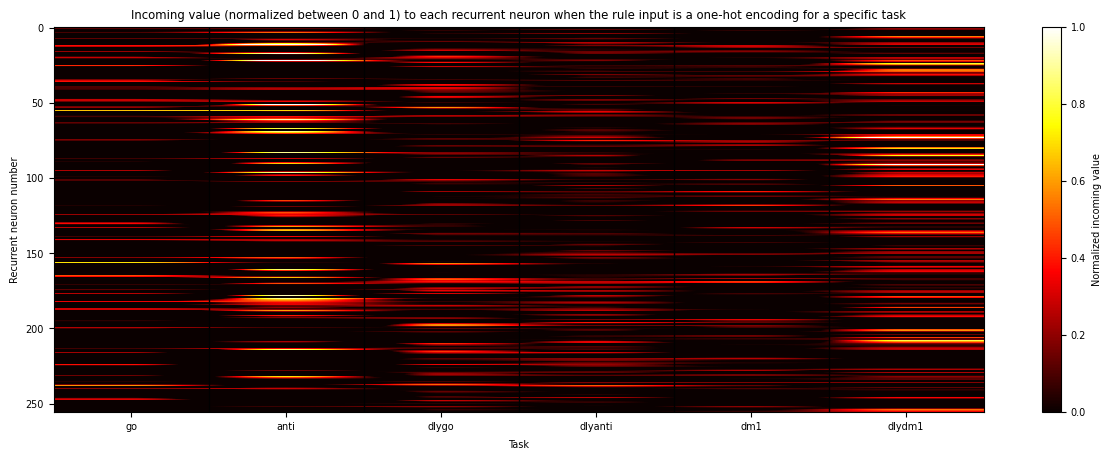

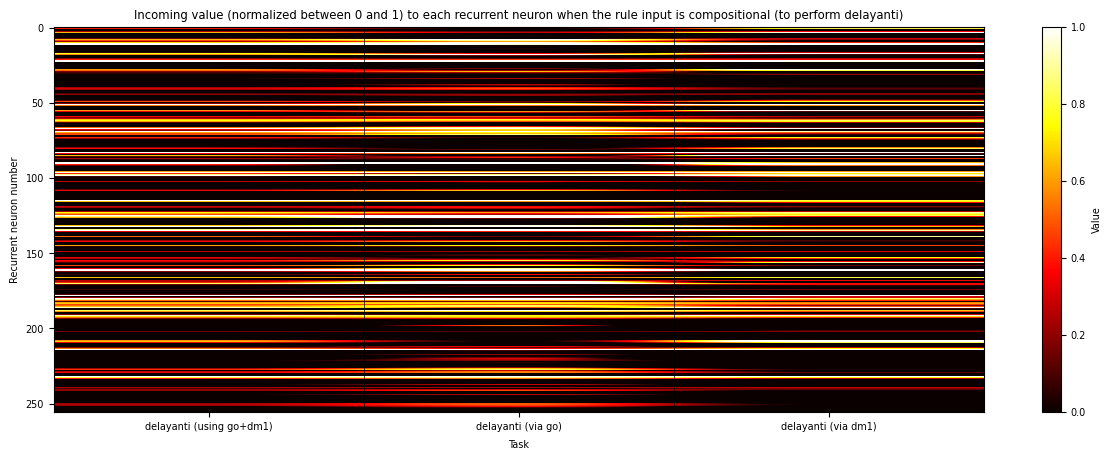

In [62]:
model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_256'

model=Model(model_dir)

#['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
#'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
#'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
#'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod'] 

learned_task_rules={'go':[1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    'anti':[0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    'dlygo':[0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    'dlyanti':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    'dm1':[0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    'dlydm1':[0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
                    #'dm2':[0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    #'dlydm2':[0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
                    #'ctxdm1':[0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
                    #'ctxdlydm1':[0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],
                    #'ctxdm2':[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
                    #'ctxdlydm2':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
                    #'multidm':[0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
                    #'multidlydm':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
                    }

compositional_task_rules={#'original delayanti':[0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                        'delayanti (using go+dm1)':0.5*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+0.5*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]),
                        'delayanti (via go)':[-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                        'delayanti (via dm1)':[0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
                        #'delayanti (via dm2)':[0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
                        #'delayanti (via ctxdm1)':[0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0],
                        #'delayanti (via ctxdm2)':[0,0,0,1,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0],
                        #'delayanti (via multidm)':[0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0]
                        }

with tf.Session() as sess:
    model.restore()

    in_weights=model.w_in.eval()
    rule_in_weights=in_weights[-22:,:]

    one_hot_rules_proj = np.empty((rule_in_weights.shape[1],0))
    comp_rules_proj = np.empty((rule_in_weights.shape[1],0))

    for task in learned_task_rules:
        rule_input = learned_task_rules[task]
        res_normal = np.expand_dims(np.matmul(rule_input, rule_in_weights),axis=1)
        one_hot_rules_proj = np.concatenate((one_hot_rules_proj, res_normal), axis=1)

    plt.figure(figsize=(15,5))
    plt.title('Incoming value (normalized between 0 and 1) to each recurrent neuron when the rule input is a one-hot encoding for a specific task')
    plt.ylabel('Recurrent neuron number')
    plt.xlabel('Task', labelpad=len([task for task in learned_task_rules]))
    plt.imshow(one_hot_rules_proj,aspect='auto',cmap='hot',vmin=0,vmax=1)
    task_list=[task for task in learned_task_rules]
    plt.xticks(range(len(task_list)),task_list)
    plt.colorbar(label="Normalized incoming value")
    for x in range(1, len(task_list)):  
        plt.axvline(x - 0.5, color='black', linewidth=1.)
    plt.show()

    for task in compositional_task_rules:
        rule_input = compositional_task_rules[task]
        res_normal = np.expand_dims(np.matmul(rule_input, rule_in_weights),axis=1)
        comp_rules_proj = np.concatenate((comp_rules_proj, res_normal), axis=1)

    plt.figure(figsize=(15,5))
    plt.title('Incoming value (normalized between 0 and 1) to each recurrent neuron when the rule input is compositional (to perform delayanti)')
    plt.ylabel('Recurrent neuron number')
    plt.xlabel('Task', labelpad=len([task for task in learned_task_rules]))
    plt.imshow(comp_rules_proj,aspect='auto',cmap='hot',vmin=0,vmax=1)
    task_list=[task for task in compositional_task_rules]
    plt.xticks(range(len(task_list)),task_list)
    plt.colorbar(label="Value")
    for x in range(1, len(task_list)):  
        plt.axvline(x - 0.5, color='black', linewidth=0.5)
    plt.show()


In [27]:
model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256'
replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

compositional_rules_delayanti={'go':[-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                     'dm1':[0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
                     'dm2':[0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
                     'contextdm1':[0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0],
                     'contextdm2':[0,0,0,1,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0],
                     'multidm':[0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0]}

compositional_rules_multidelaydm={'go':[-1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],
                     'dm1':[0,0,0,0,0,0,-1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0],
                     'dm2':[0,0,0,0,0,0,0,-1,0,0,1,0,1,0,0,0,0,0,0,0,0,0],
                     'contextdm1':[0,0,0,0,0,0,0,0,-1,0,1,0,0,1,0,0,0,0,0,0,0,0],
                     'contextdm2':[0,0,0,0,0,0,0,0,0,-1,1,0,0,0,1,0,0,0,0,0,0,0],
                     'anti':[0,0,0,-1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0]}

pure_tasks_perfs=[]
comp_tasks_perf=[]

for i in range(len(replace_rule)):

    rule_strength=[0]*len(replace_rule)
    rule_strength[i]=1
    perf, _ = taskset.run_network_replacerule(model_dir, replace_rule[i], replace_rule, rule_strength)
    pure_tasks_perfs.append(perf)

for el in compositional_rules_delayanti:

    perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, compositional_rules_delayanti[el])
    comp_tasks_perf.append((el,perf))

for i in range(len(replace_rule)):

    print(f'Performance on task {replace_rule[i]}: ', pure_tasks_perfs[i])

for (fam,perf) in comp_tasks_perf:

    print(f'Performance on delayanti when instructed with {fam} family: ', perf)

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt


Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_delayanti_256/hp.json
INFO:tensorf

In [ ]:
import numpy as np
from analysis import taskset
import os

model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'
replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

grid=np.linspace(-5,5,11)

performances=np.zeros(shape=(11,11))

for i,a in enumerate(grid):
    for j,b in enumerate(grid):

        rule_strength= a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        b*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0])
                        
        perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, rule_strength)
        performances[i,j]=perf

np.save(os.path.join(model_dir,'comp_rule_linear_comb_neg.npy'),performances)
        


In [ ]:
model_dir = './../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'
performances = np.load(os.path.join(model_dir, 'comp_rule_linear_comb_neg.npy'), allow_pickle=True)

plt.imshow(performances)
plt.xticks(np.arange(0, performances.shape[1], 1))
plt.yticks(np.arange(0, performances.shape[0], 1))
plt.gca().set_xticklabels([int(x) for x in np.linspace(-5, 5, performances.shape[1])])
plt.gca().set_yticklabels([int(x) for x in np.linspace(-5, 5, performances.shape[0])])
plt.xlabel('b value')
plt.ylabel('a value')
plt.title('Performances for rule inputs in the form \n a(delaygo-go+anti)+b(delaydm1-dm1+anti)')
plt.colorbar()

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import itertools
%matplotlib widget

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb_2.npy'), allow_pickle=True)

values = [x / 10 for x in range(11)]
combinations = itertools.product(values, repeat=6)
valid_combinations = sum(0.8 <= sum(comb) <= 1.2 for comb in combinations)

print('Number of values in the [0.8,1.2] section:\t\t',valid_combinations)
print('Number of actual non-zero values in the 6D matrix:\t',sum([ x!=0 for x in performance_array.flatten()]))

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
%matplotlib widget

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb.npy'), allow_pickle=True)

perf=performance_array#[:,0,0,0,:,:]

print(f"Shape of 'perf': {perf.shape}")

x_dim, y_dim, z_dim = perf.shape
x = np.linspace(0,1,x_dim)
y = np.linspace(0,1,y_dim)
z = np.linspace(0,1,z_dim)

x_grid, y_grid, z_grid = np.meshgrid(x, y, z, indexing='ij')
x_vals = x_grid.flatten()
y_vals = y_grid.flatten()
z_vals = z_grid.flatten()
perf_vals = perf.flatten()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scat = ax.scatter(x_vals, y_vals, z_vals, c=perf_vals, cmap='viridis')
fig.colorbar(scat)
ax.set_xlabel('a axis')
ax.set_ylabel('b axis')
ax.set_zlabel('c axis')
plt.title('3D Scatter Plot with Performance Values as Color')
plt.show()

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
Overwrite sigma_rec with 0.000
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
delayanti
OrderedDict([(-0.0, array([[[1.66192022e-03, 9.80826328e-04, 1.06593800e+00, ...,
         1.42141104e-01, 2.47902726e-03, 4.65065986e-02],
        [1.69961015e-03, 1.01797865e-03, 1.05996406e+00, ...,
         1.38131201e-01, 2.56504654e-03, 3.56606543e-02],
        [1.67333276e-03, 9.76607786e-04, 1.07246590e+00, ...,
         1.42309278e-01, 2.44427612e-03, 3.89321744e-02],
        ...,
        [1.74534321e-03, 1.20063708e-03, 1.07186818e+00, ...,
         1.37779713e-01, 2.39378074e-03, 3.53746116e-02],
        [1.66575622e-03, 1.00835157e-03, 1.06452286e+00, ...,
         1.42005220e-01, 2.50553899e-03, 4.61167246e-02],
        [1.69601303e-03, 1.10457698e-03, 1.06061614e+00, ...,
         1.38279736e-01, 2.46891193e-03, 3.77425998e-02]],

       [[1.52218097e-03, 8.92778509e-04, 9.40892994e-01, ...,
         1.35101140e-01, 2.49497592e-03, 6.70153871e-02],
        [1.58196141e-03, 9.6

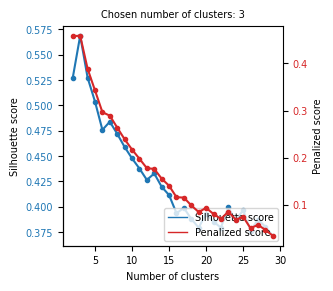

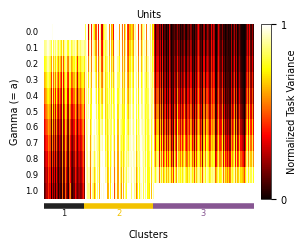

In [131]:
model_dir=['./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024']

#calculate task variance..
#defined as the variance of a hidden unit activation across the test
#set for each task

from analysis import variance

def compute_variance_bias(model_dirs, rules=None, random_rotation=False, replace_rule=None, rule_strengths=None):
    """Compute variance for all tasks.

    Args:
        model_dir: str, the path of the model directory
        rules: list of rules to compute variance, list of strings
        random_rotation: boolean. If True, rotate the neural activity.
    """
    for d in model_dirs:
        variance._compute_variance(d, rules, random_rotation, replace_rule, rule_strengths)

replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

grid=np.linspace(0,1,11)

rule_strengths=[]

for i,a in enumerate(grid):

        rule_strengths.append(a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        (1-a)*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]))

compute_variance_bias(model_dir, rules='delayanti', random_rotation=False, replace_rule=replace_rule, rule_strengths=rule_strengths)

print("################################################")
CA = clustering.Analysis(model_dir, data_type='rule')  #epoch or rule
CA.plot_cluster_score()
CA.plot_compositional_variance()

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
Overwrite sigma_rec with 0.000
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
['fdgo', 'fdanti', 'delaygo', 'delaydm1', 'dm1']


OrderedDict([('fdgo', array([[[1.37288123e-03, 9.96991294e-04, 3.86316299e-01, ...,
         1.19231595e-02, 4.94696153e-03, 2.06418149e-02],
        [1.39792671e-03, 1.03311939e-03, 3.83891940e-01, ...,
         1.16268145e-02, 5.15123550e-03, 1.57767795e-02],
        [1.38045952e-03, 9.92868096e-04, 3.89014751e-01, ...,
         1.19357184e-02, 4.86436673e-03, 1.72289386e-02],
        ...,
        [1.42830599e-03, 1.21073343e-03, 3.88765514e-01, ...,
         1.16011109e-02, 4.74435650e-03, 1.56504512e-02],
        [1.37543119e-03, 1.02375436e-03, 3.85738105e-01, ...,
         1.19130407e-02, 5.00994129e-03, 2.04644129e-02],
        [1.39552006e-03, 1.11731340e-03, 3.84154439e-01, ...,
         1.16377082e-02, 4.92293248e-03, 1.66993998e-02]],

       [[1.27041677e-03, 9.37090779e-04, 3.43265533e-01, ...,
         1.14365788e-02, 5.24331955e-03, 3.11116390e-02],
        [1.28306844e-03, 9.87387146e-04, 3.38888377e-01, ...,
         1.04202908e-02, 5.47627779e-03, 1.78936124e-02],
   

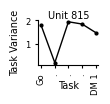

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


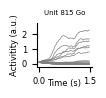

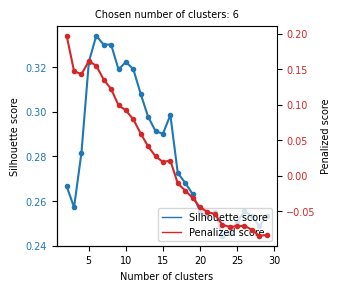

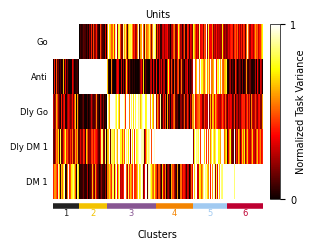

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
./../mod

(array([[ 0.        ,  0.        ,  0.        , -0.02734375,  0.01171875],
        [ 0.        , -0.890625  ,  0.        , -0.296875  , -0.0546875 ],
        [-0.86328125, -0.00390625, -0.67578125, -0.796875  , -0.5234375 ],
        [ 0.        , -0.3359375 , -0.0703125 , -0.3828125 , -0.26171875],
        [ 0.        ,  0.        , -0.046875  , -0.18359375, -0.3359375 ],
        [-0.01171875,  0.        , -0.0546875 , -0.1328125 , -0.390625  ]]),
 array([[0.02620697, 0.00191513, 0.00987555, 0.01737878, 0.00135869],
        [0.00537123, 0.48692566, 0.01436491, 0.15283076, 0.04798781],
        [0.33799997, 0.05129233, 0.34806365, 0.30422235, 0.28531083],
        [0.01304665, 0.12549914, 0.04249851, 0.17631252, 0.2027469 ],
        [0.01296135, 0.05678598, 0.06325323, 0.09688466, 0.23732376],
        [0.02411823, 0.00286884, 0.03898958, 0.05450395, 0.25091136]],
       dtype=float32))

In [28]:
model_dir=['./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024']

#calculate task variance..
#defined as the variance of a hidden unit activation across the test
#set for each task

from analysis import variance

def compute_variance_bias(model_dirs, rules=None, random_rotation=False):
    """Compute variance for all tasks.

    Args:
        model_dir: str, the path of the model directory
        rules: list of rules to compute variance, list of strings
        random_rotation: boolean. If True, rotate the neural activity.
    """
    for d in model_dirs:
        variance._compute_variance(d, rules, random_rotation)

compute_variance_bias(model_dir, rules=None, random_rotation=False)

CA = clustering.Analysis(model_dir, data_type='rule')
CA.plot_example_unit()
CA.plot_cluster_score()
CA.plot_variance()
CA.lesions()

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
Overwrite sigma_rec with 0.000


INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
delayanti
OrderedDict([(-0.0, array([[[1.66192022e-03, 9.80826328e-04, 1.06593800e+00, ...,
         1.42141104e-01, 2.47902726e-03, 4.65065986e-02],
        [1.69961015e-03, 1.01797865e-03, 1.05996406e+00, ...,
         1.38131201e-01, 2.56504654e-03, 3.56606543e-02],
        [1.67333276e-03, 9.76607786e-04, 1.07246590e+00, ...,
         1.42309278e-01, 2.44427612e-03, 3.89321744e-02],
        ...,
        [1.74534321e-03, 1.20063708e-03, 1.07186818e+00, ...,
         1.37779713e-01, 2.39378074e-03, 3.53746116e-02],
        [1.66575622e-03, 1.00835157e-03, 1.06452286e+00, ...,
         1.42005220e-01, 2.50553899e-03, 4.61167246e-02],
        [1.69601303e-03, 1.10457698e-03, 1.06061614e+00, ...,
         1.38279736e-01, 2.46891193e-03, 3.77425998e-02]],

       [[1.52218097e-03, 8.92778509e-04, 9.40

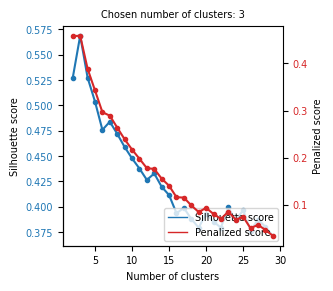

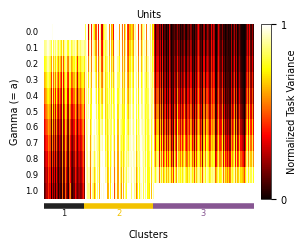

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 

In [152]:
model_dir=['./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024']

#calculate task variance..
#defined as the variance of a hidden unit activation across the test
#set for each task

from analysis import variance

def compute_variance_bias(model_dirs, rules=None, random_rotation=False, replace_rule=None, rule_strengths=None):
    """Compute variance for all tasks.

    Args:
        model_dir: str, the path of the model directory
        rules: list of rules to compute variance, list of strings
        random_rotation: boolean. If True, rotate the neural activity.
    """
    for d in model_dirs:
        variance._compute_variance(d, rules, random_rotation, replace_rule, rule_strengths)

replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

grid=np.linspace(0,1,11)

rule_strengths=[]

for i,a in enumerate(grid):

        rule_strengths.append(a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        (1-a)*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]))

compute_variance_bias(model_dir, rules='delayanti', random_rotation=False, replace_rule=replace_rule, rule_strengths=rule_strengths)

print("################################################")
CA = clustering.Analysis(model_dir, data_type='rule')  #epoch or rule
CA.plot_cluster_score()
CA.plot_compositional_variance()

lab=CA.labels
print(lab)
print(np.unique(lab))
print(lab.shape)

active=CA.ind_active
print(active)
print(active.shape)

passive=np.array([i for i in np.arange(1024) if i not in CA.ind_active])
print(passive)
print(passive.shape)

print(f'Shape of cluster 1: {active[lab==0].shape}')
print(f'Shape of cluster 2: {active[lab==1].shape}')
print(f'Shape of cluster 3: {active[lab==2].shape}')

In [154]:
import collections

model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'

comp_tasks_perf=collections.defaultdict(list)
model=Model(model_dir)

with tf.Session() as sess:
    model.restore()
    #model.lesion_units(sess, off)
    #variance._compute_variance_bymodel(model, sess, rules='delayanti', random_rotation=False, replace_rule=replace_rule, rule_strengths=rule_strengths)
    for el,rule_strength in enumerate(rule_strengths):

        batch_size_test = 1000
        n_rep = 20
        batch_size_test_rep = int(batch_size_test/n_rep)
        perf_rep = list()
        for i_rep in range(n_rep):
            trial = taskset.generate_trials('delayanti', model.hp, 'random', batch_size=batch_size_test_rep,
                                     replace_rule=replace_rule, rule_strength=rule_strength)
            feed_dict = tools.gen_feed_dict(model, trial, model.hp)
            y_hat_test = sess.run(model.y_hat, feed_dict=feed_dict)

            perf_rep.append(np.mean(taskset.get_perf(y_hat_test, trial.y_loc)))

        perf,_=np.mean(perf_rep), rule_strength
        comp_tasks_perf[el].append(perf)

model=Model(model_dir)

for cluster in range(3):
    with tf.Session() as sess:
        model.restore()

        new_active=active[lab==cluster]

        off=np.concatenate((new_active,passive))

        model.lesion_units(sess, off)
        #variance._compute_variance_bymodel(model, sess, rules='delayanti', random_rotation=False, replace_rule=replace_rule, rule_strengths=rule_strengths)
        for el,rule_strength in enumerate(rule_strengths):

            batch_size_test = 1000
            n_rep = 20
            batch_size_test_rep = int(batch_size_test/n_rep)
            perf_rep = list()
            for i_rep in range(n_rep):
                trial = taskset.generate_trials('delayanti', model.hp, 'random', batch_size=batch_size_test_rep,
                                        replace_rule=replace_rule, rule_strength=rule_strength)
                feed_dict = tools.gen_feed_dict(model, trial, model.hp)
                y_hat_test = sess.run(model.y_hat, feed_dict=feed_dict)

                perf_rep.append(np.mean(taskset.get_perf(y_hat_test, trial.y_loc)))

            perf,_=np.mean(perf_rep), rule_strength
            comp_tasks_perf[el].append(perf)

print(comp_tasks_perf)


./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
<tf.Variable 'rnn/leaky_rnn_cell/kernel:0' shape=(1111, 1024) dtype=float32_ref>
<tf.Variable 'rnn/leaky_rnn_cell/bias:0' shape=(1024,) dtype=float32_ref>
<tf.Variable 'output/weights:0' shape=(1024, 33) dtype=float32_ref>
<tf.Variable 'output/biases:0' shape=(33,) dtype=float32_ref>
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
<tf.Variable 'rnn/leaky_rnn_cell/kernel:0' shape=(1111, 1024) dtype=float32_ref>
<tf.Variable 'rnn/leaky_rnn_cell/bias:0' shape=(1024,) dtype=float32_ref>
<tf.Variable 'output/weights:0' sha

In [89]:
import pandas as pd 

table=[]

for el,row in comp_tasks_perf.items():
    table.append(row)

table=pd.DataFrame(table)
table.columns=['No removed clusters','Cluster 1 removed','Cluster 2 removed','Cluster 3 removed']
table.index=[np.linspace(0,1,11)]
table

,No removed clusters,Cluster 1 removed,Cluster 2 removed,Cluster 3 removed
0.0,0.877,0.239,0.314,0.554
0.1,0.828,0.312,0.302,0.571
0.2,0.793,0.279,0.313,0.581
0.3,0.932,0.277,0.280,0.659
0.4,0.927,0.280,0.225,0.657
0.5,0.940,0.276,0.224,0.662
0.6,0.962,0.339,0.251,0.698
0.7,0.870,0.338,0.153,0.790
0.8,0.811,0.260,0.145,0.776
0.9,0.941,0.304,0.177,0.764


./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2

Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
(1024,)
(1024,)
(2, 1024)


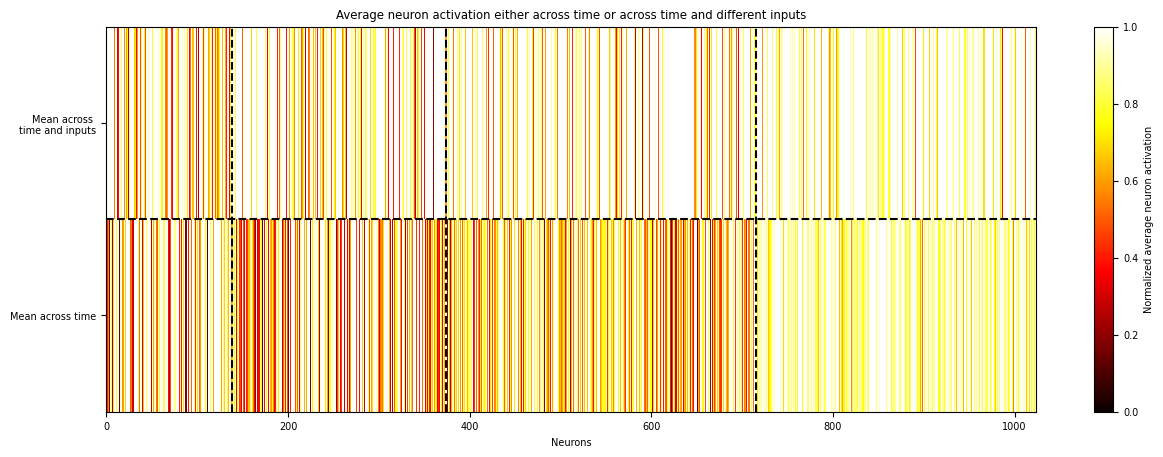

(11, 1024)
(11, 1024)


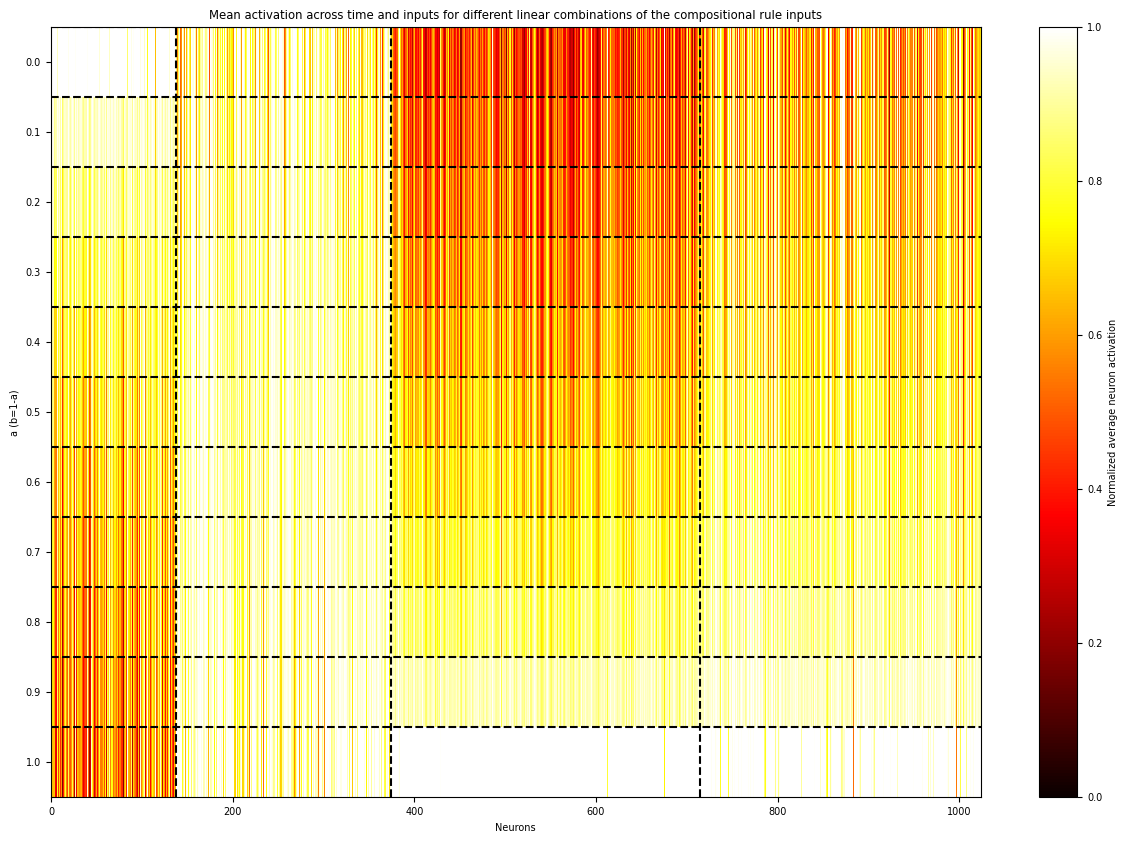

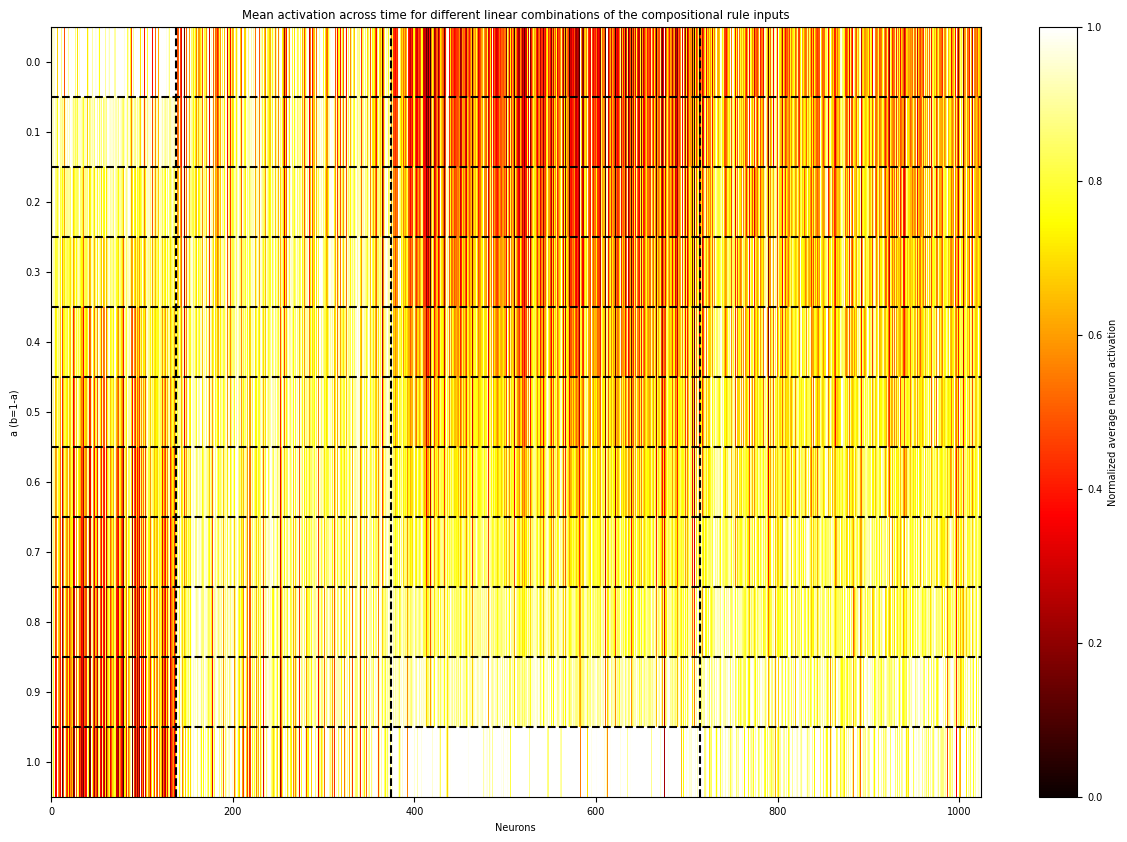

In [140]:
model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'

model=Model(model_dir)

replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

target_trial=0

grid=np.linspace(0,1,11)

rule_strengths=[]

for i,a in enumerate(grid):

        rule_strengths.append(a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        (1-a)*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]))

print(CA.labels)
print(CA.ind_active)

active_labels=CA.labels
active_indices=CA.ind_active

passive_indices=np.array([i for i in np.arange(1024) if i not in CA.ind_active])
passive_labels=np.array([3]*len(passive_indices))

tot_indices=np.concatenate((active_indices,passive_indices))
tot_labels=np.concatenate((active_labels,passive_labels))

print(tot_indices)
print(tot_labels)
print(tot_indices.shape)
print(tot_labels.shape)

mix=np.argsort(tot_indices)
tot_labels=tot_labels[mix]
tot_indices=tot_indices[mix]
print(tot_labels)
print(tot_indices)
mix=np.argsort(tot_labels)


print(f'Shape of cluster 1: {active[lab==0].shape}')
print(f'Shape of cluster 2: {active[lab==1].shape}')
print(f'Shape of cluster 3: {active[lab==2].shape}')
print(f'Shape of cluster of inactive: {passive_indices.shape}')

rule_strength=rule_strengths[0]

with tf.Session() as sess:

    model.restore()
    trial = taskset.generate_trials('delayanti', model.hp, 'test', noise_on=False, replace_rule=replace_rule, rule_strength=rule_strength)
    feed_dict = tools.gen_feed_dict(model, trial, model.hp)
    h = sess.run(model.h, feed_dict=feed_dict)  #(time,batchsize,neurons)

    data1=h.T.mean(axis=1).mean(axis=1)[mix]
    data2=h.T[:,target_trial,:].mean(axis=1)[mix]

    print(data1.shape)
    print(data2.shape)
    
    data=np.concatenate((data1.reshape(1,len(data1)),data2.reshape(1,len(data2))),axis=0)
    print(data.shape)

    data=data/np.max(data,axis=0)

    fig1,ax1=plt.subplots(figsize=(15,5))

    im1=ax1.imshow(data,cmap='hot',aspect='auto',interpolation='none',vmax=1,vmin=0)
    ax1.set_yticks([0,1])
    ax1.set_yticklabels(['Mean across \ntime and inputs','Mean across time'])
    ax1.set_xlabel('Neurons')
    ax1.set_title('Average neuron activation either across time or across time and different inputs')
    cbar1=fig1.colorbar(im1)
    cbar1.set_label('Normalized average neuron activation')

    ax1.axhline(0.5,color = 'black', linestyle='--')
    prev=0
    for lab in np.unique(CA.labels):
        curr_count=len(tot_labels[tot_labels==lab])
        ax1.axvline(len(tot_labels[tot_labels==lab])+prev,color = 'black', linestyle='--')
        prev=prev+curr_count

    plt.show()

    data_t_i=[]
    data_t=[]

    for rule_strength in rule_strengths:

        trial = taskset.generate_trials('delayanti', model.hp, 'test', noise_on=False, replace_rule=replace_rule, rule_strength=rule_strength)
        feed_dict = tools.gen_feed_dict(model, trial, model.hp)
        h = sess.run(model.h, feed_dict=feed_dict)  #(time,batchsize,neurons)

        data1=h.T.mean(axis=1).mean(axis=1)
        data2=h.T[:,target_trial,:].mean(axis=1)
        
        #data1=data1.reshape((1,len(data1)))
        #data2=data2.reshape((1,len(data2)))

        data_t_i.append(data1)
        data_t.append(data2)
    
    data_t_i=data_t_i/np.max(data_t_i,axis=0)
    data_t=data_t/np.max(data_t,axis=0)

    data_t_i=np.array(data_t_i)[:,mix]
    data_t=np.array(data_t)[:,mix]

    print(data_t_i.shape)
    print(data_t.shape)

    fig2,ax2=plt.subplots(figsize=(15,10))

    im2=ax2.imshow(data_t_i,cmap='hot',aspect='auto',interpolation='none',vmax=1,vmin=0)
    ax2.set_yticks([0,1,2,3,4,5,6,7,8,9,10])
    ax2.set_title('Mean activation across time and inputs for different linear combinations of the compositional rule inputs')
    ax2.set_xlabel('Neurons')
    ax2.set_ylabel('a (b=1-a)')
    ax2.set_yticklabels([int(n*10)/10 for n in np.linspace(0,1,11)])
    cbar2=fig2.colorbar(im2)
    cbar2.set_label('Normalized average neuron activation')

    for a in np.linspace(0,1,11):
        ax2.axhline(a*10 - 0.5,color = 'black', linestyle='--')
    prev=0
    for lab in np.unique(CA.labels):
        curr_count=len(tot_labels[tot_labels==lab])
        ax2.axvline(len(tot_labels[tot_labels==lab])+prev,color = 'black', linestyle='--')
        prev=prev+curr_count

    plt.show()

    fig3,ax3=plt.subplots(figsize=(15,10))

    im3=ax3.imshow(data_t,cmap='hot',aspect='auto',interpolation='none',vmax=1,vmin=0)
    ax3.set_yticks([0,1,2,3,4,5,6,7,8,9,10])
    ax3.set_title('Mean activation across time for different linear combinations of the compositional rule inputs')
    ax3.set_xlabel('Neurons')
    ax3.set_ylabel('a (b=1-a)')
    ax3.set_yticklabels([int(n*10)/10 for n in np.linspace(0,1,11)])
    cbar3=fig3.colorbar(im3)
    cbar3.set_label('Normalized average neuron activation')

    for a in np.linspace(0,1,11):
        ax3.axhline(a*10 - 0.5,color = 'black', linestyle='--')
    prev=0
    for lab in np.unique(CA.labels):
        curr_count=len(tot_labels[tot_labels==lab])
        ax3.axvline(len(tot_labels[tot_labels==lab])+prev,color = 'black', linestyle='--')
        prev=prev+curr_count

    plt.show()

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
Shape of cluster 1: (138,)
Shape of cluster 2: (236,)
Shape of cluster 3: (341,)
Shape of cluster of inactive: (309,)
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
(11, 1024)


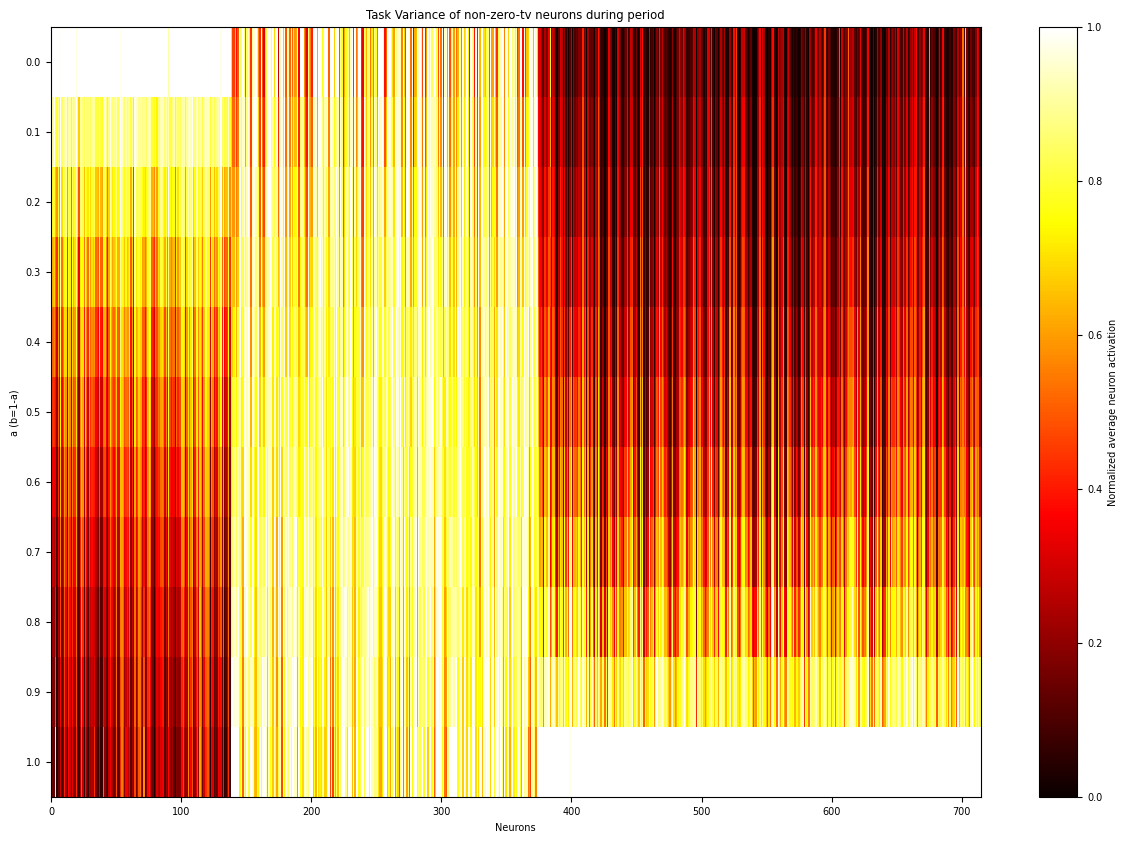

In [135]:
model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'

model=Model(model_dir)

replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

target_trial=0

grid=np.linspace(0,1,11)

rule_strengths=[]

for i,a in enumerate(grid):

        rule_strengths.append(a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        (1-a)*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]))
        
active_labels=CA.labels
active_indices=CA.ind_active

passive_indices=np.array([i for i in np.arange(1024) if i not in CA.ind_active])
passive_labels=np.array([3]*len(passive_indices))

tot_indices=np.concatenate((active_indices,passive_indices))
tot_labels=np.concatenate((active_labels,passive_labels))

mix=np.argsort(tot_indices)
tot_labels=tot_labels[mix]
tot_indices=tot_indices[mix]
mix=np.argsort(tot_labels)


print(f'Shape of cluster 1: {active[lab==0].shape}')
print(f'Shape of cluster 2: {active[lab==1].shape}')
print(f'Shape of cluster 3: {active[lab==2].shape}')
print(f'Shape of cluster of inactive: {passive_indices.shape}')

rule_strength=rule_strengths[0]

with tf.Session() as sess:

    model.restore()

    data=[]

    for rule_strength in rule_strengths:

        trial = taskset.generate_trials('delayanti', model.hp, 'test', noise_on=False, replace_rule=replace_rule, rule_strength=rule_strength)
        feed_dict = tools.gen_feed_dict(model, trial, model.hp)
        h = sess.run(model.h, feed_dict=feed_dict)  #(time,batchsize,neurons)

        tv=h.var(axis=1).mean(axis=0)
        data.append(tv)

    data=np.concatenate([act.reshape(1,len(act)) for act in data])

    print(data.shape)
    data=data[:,mix]

    data=data[:,:-len(passive)]
    data=data/np.max(data,axis=0)

    fig,ax=plt.subplots(figsize=(15,10))

    im=ax.imshow(data,cmap='hot',aspect='auto',interpolation='nearest',vmax=1,vmin=0)
    ax.set_yticks([0,1,2,3,4,5,6,7,8,9,10])
    ax.set_title(f'Task Variance of non-zero-tv neurons during period')
    ax.set_xlabel('Neurons')
    ax.set_ylabel('a (b=1-a)')
    ax.set_yticklabels([int(n*10)/10 for n in np.linspace(0,1,11)])
    cbar=fig.colorbar(im)
    cbar.set_label('Normalized average neuron activation')
    plt.show()

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
Shape of cluster 1: (0, 715)
Shape of cluster 2: (0, 715)
Shape of cluster 3: (1, 715)
Shape of cluster of inactive: (309,)
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


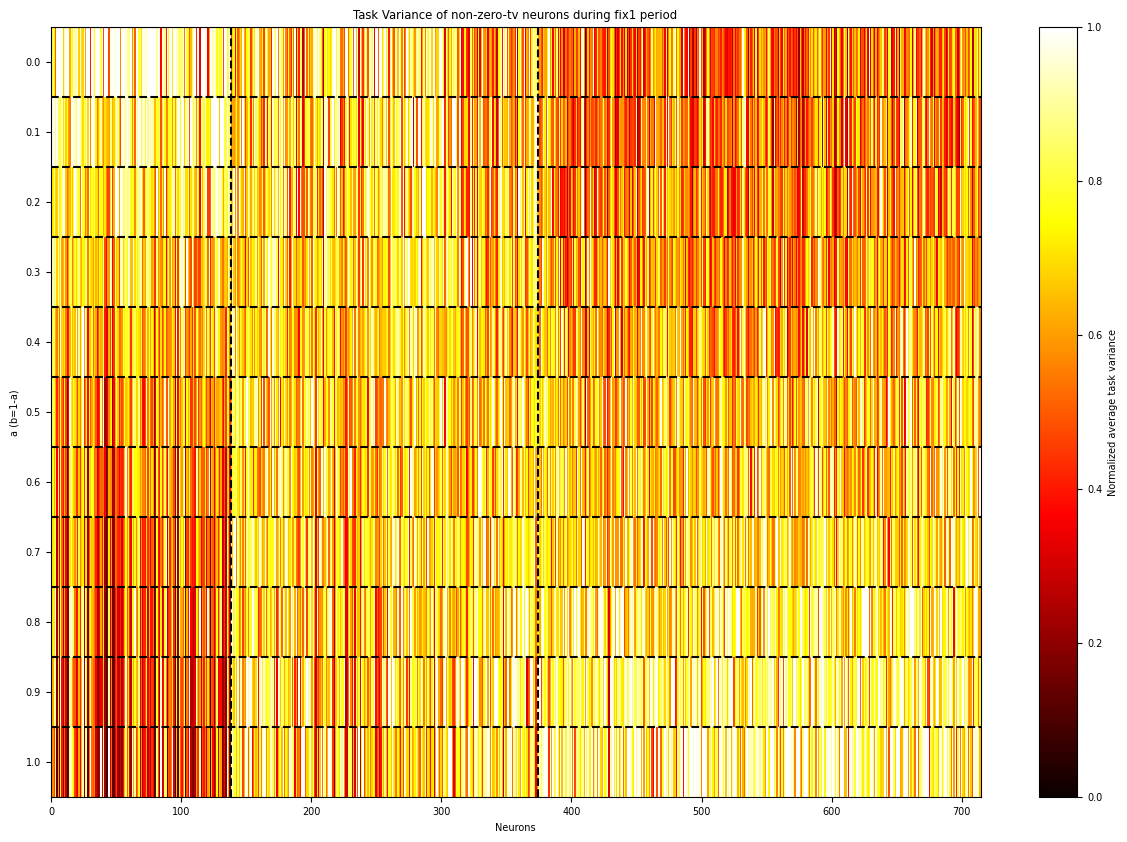

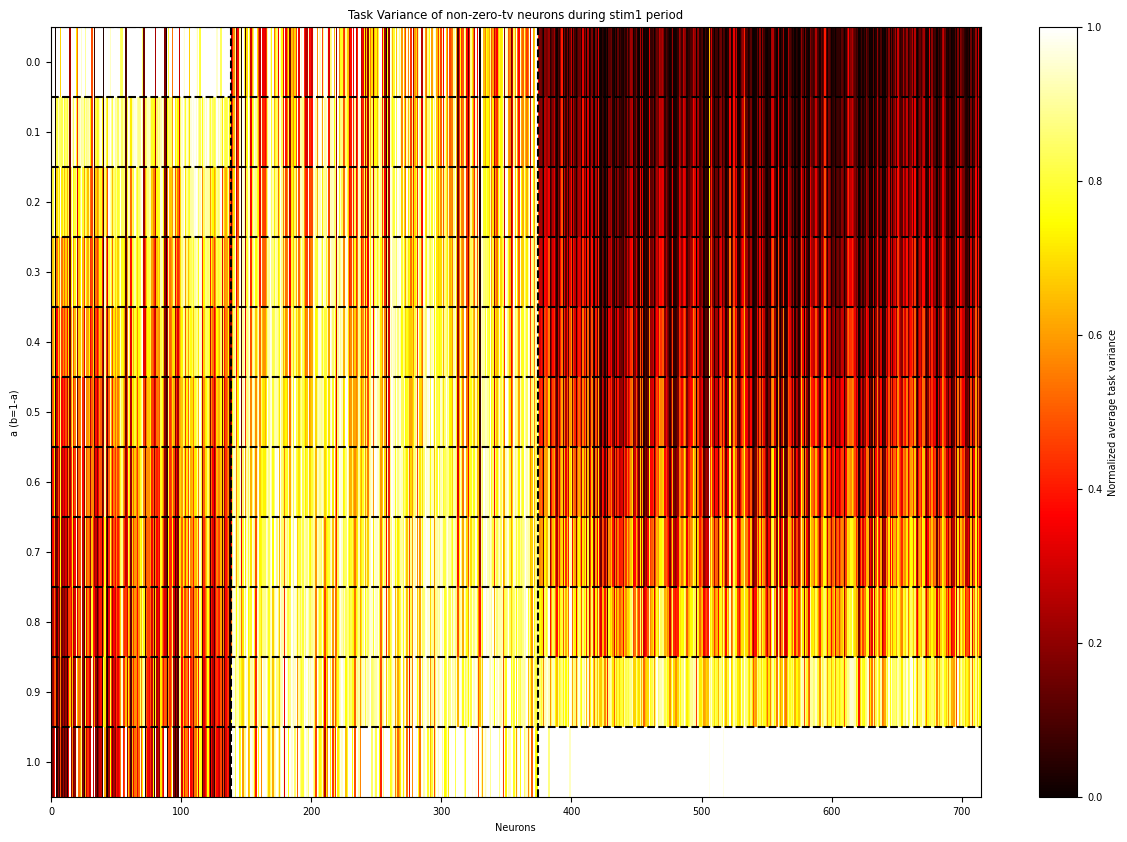

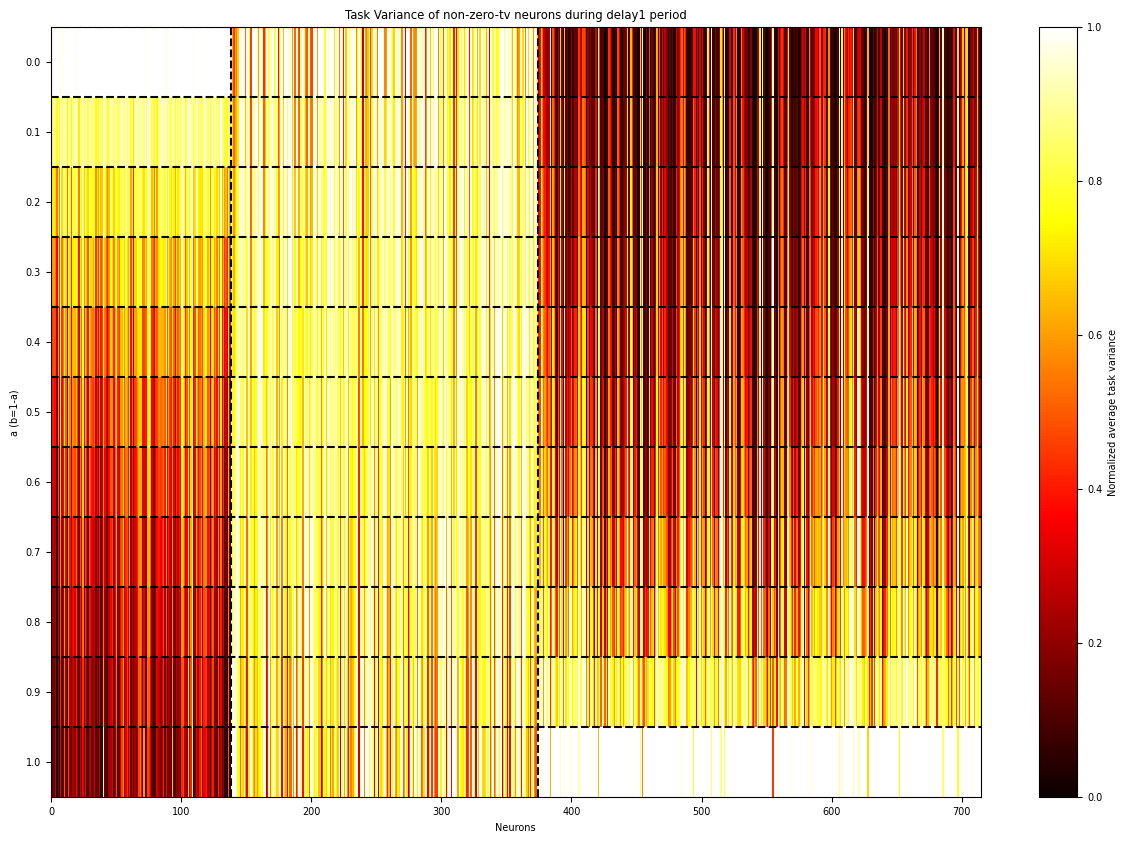

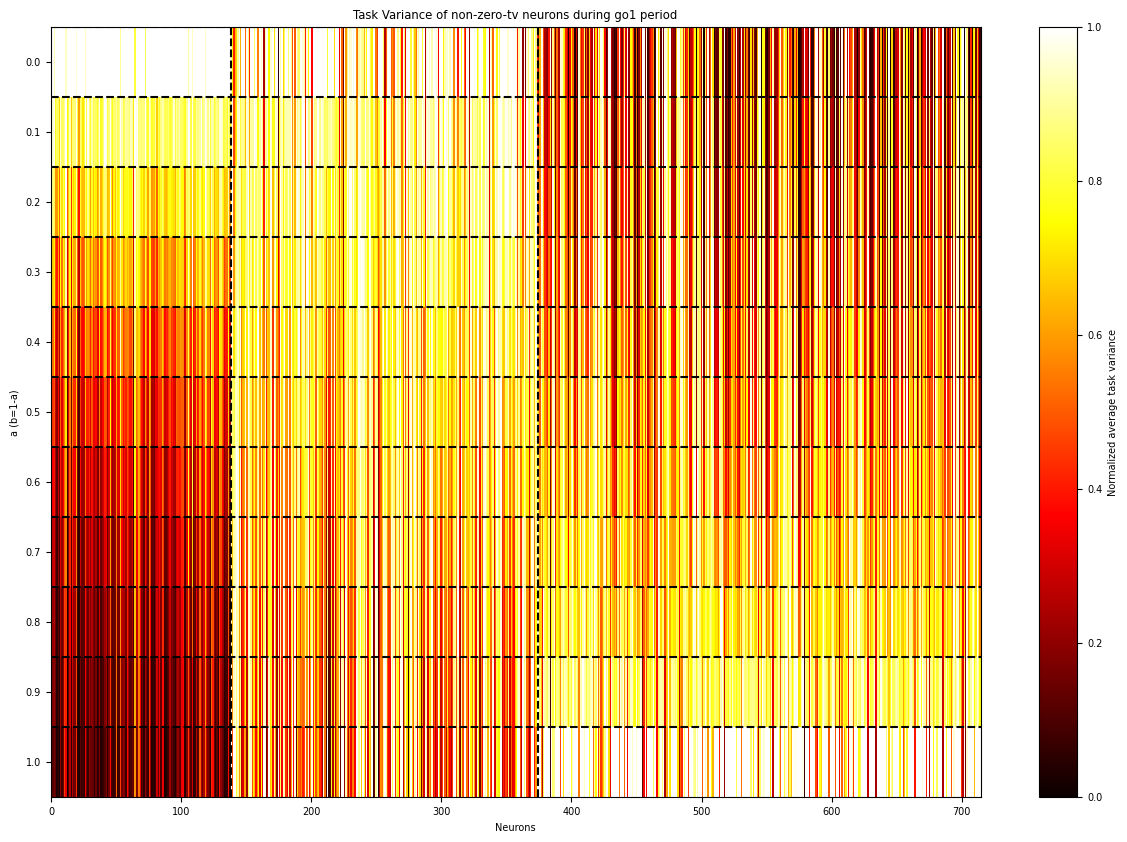

In [147]:
model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'

model=Model(model_dir)

replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

target_trial=0

grid=np.linspace(0,1,11)

rule_strengths=[]

for i,a in enumerate(grid):

        rule_strengths.append(a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        (1-a)*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]))
        
active_labels=CA.labels
active_indices=CA.ind_active

passive_indices=np.array([i for i in np.arange(1024) if i not in CA.ind_active])
passive_labels=np.array([3]*len(passive_indices))

tot_indices=np.concatenate((active_indices,passive_indices))
tot_labels=np.concatenate((active_labels,passive_labels))

mix=np.argsort(tot_indices)
tot_labels=tot_labels[mix]
tot_indices=tot_indices[mix]
mix=np.argsort(tot_labels)


print(f'Shape of cluster 1: {active[lab==0].shape}')
print(f'Shape of cluster 2: {active[lab==1].shape}')
print(f'Shape of cluster 3: {active[lab==2].shape}')
print(f'Shape of cluster of inactive: {passive_indices.shape}')

rule_strength=rule_strengths[0]

with tf.Session() as sess:

    model.restore()

    data={'fix1':[],
          'stim1':[],
          'delay1':[],
          'go1':[]}

    for rule_strength in rule_strengths:

        trial = taskset.generate_trials('delayanti', model.hp, 'test', noise_on=False, replace_rule=replace_rule, rule_strength=rule_strength)
        feed_dict = tools.gen_feed_dict(model, trial, model.hp)
        h = sess.run(model.h, feed_dict=feed_dict)  #(time,batchsize,neurons)

        for (name, (start,end)) in trial.epochs.items():
            
            activations=h[start:end,:,:]
            tv=activations.var(axis=1).mean(axis=0)
            data[name].append(tv)

    for period in data:

        period_data=np.array(data[period])

        period_data=period_data[:,mix]

        period_data=period_data[:,:-len(passive)]

        period_data=period_data/np.max(period_data,axis=0)

        fig,ax=plt.subplots(figsize=(15,10))

        im=ax.imshow(period_data,cmap='hot',aspect='auto',interpolation='none',vmax=1,vmin=0)
        ax.set_yticks([0,1,2,3,4,5,6,7,8,9,10])
        ax.set_title(f'Task Variance of non-zero-tv neurons during {period} period')
        ax.set_xlabel('Neurons')
        ax.set_ylabel('a (b=1-a)')
        ax.set_yticklabels([int(n*10)/10 for n in np.linspace(0,1,11)])
        cbar=fig.colorbar(im)
        cbar.set_label('Normalized average task variance')

        for a in np.linspace(0,1,11):
            ax.axhline(a*10 - 0.5,color = 'black', linestyle='--')
        prev=0
        for lab in np.unique(CA.labels)[:-1]:
            curr_count=len(tot_labels[tot_labels==lab])
            ax.axvline(len(tot_labels[tot_labels==lab])+prev,color = 'black', linestyle='--')
            prev=prev+curr_count
        
        plt.show()

In [178]:
import collections
import pandas as pd 

model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'

replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

grid=np.linspace(0,1,11)

rule_strengths=[]

for i,a in enumerate(grid):

        rule_strengths.append(a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        (1-a)*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]))

comp_tasks_perf=collections.defaultdict(list)
model=Model(model_dir)

with tf.Session() as sess:
    model.restore()
    #model.lesion_units(sess, off)
    #variance._compute_variance_bymodel(model, sess, rules='delayanti', random_rotation=False, replace_rule=replace_rule, rule_strengths=rule_strengths)
    for el,rule_strength in enumerate(rule_strengths):

        batch_size_test = 1000
        n_rep = 20
        batch_size_test_rep = int(batch_size_test/n_rep)
        perf_rep = list()
        for i_rep in range(n_rep):
            trial = taskset.generate_trials('delayanti', model.hp, 'random', batch_size=batch_size_test_rep,
                                     replace_rule=replace_rule, rule_strength=rule_strength)
            feed_dict = tools.gen_feed_dict(model, trial, model.hp)
            y_hat_test = sess.run(model.y_hat, feed_dict=feed_dict)

            perf_rep.append(np.mean(taskset.get_perf(y_hat_test, trial.y_loc)))

        perf,_=np.mean(perf_rep), rule_strength
        comp_tasks_perf[el].append(perf)

model=Model(model_dir)

for cluster in range(3):
    with tf.Session() as sess:
        model.restore()

        cluster_neurons=active[lab==cluster]

        model.lesion_units(sess, passive)
        #variance._compute_variance_bymodel(model, sess, rules='delayanti', random_rotation=False, replace_rule=replace_rule, rule_strengths=rule_strengths)
        for el,rule_strength in enumerate(rule_strengths):

            trial = taskset.generate_trials('delayanti', model.hp, 'test', noise_on=False, replace_rule=replace_rule, rule_strength=rule_strength)
            feed_dict = tools.gen_feed_dict(model, trial, model.hp)
            h = sess.run(model.h, feed_dict=feed_dict)  #(time,batchsize,neurons)

            activations=h.T.mean(axis=1).mean(axis=1)[cluster_neurons]
            model.set_unit_activations(sess,cluster_neurons,[np.mean(activations)]*len(cluster_neurons))

            batch_size_test = 1000
            n_rep = 20
            batch_size_test_rep = int(batch_size_test/n_rep)
            perf_rep = list()
            for i_rep in range(n_rep):
                trial = taskset.generate_trials('delayanti', model.hp, 'random', batch_size=batch_size_test_rep,
                                        replace_rule=replace_rule, rule_strength=rule_strength)
                feed_dict = tools.gen_feed_dict(model, trial, model.hp)
                y_hat_test = sess.run(model.y_hat, feed_dict=feed_dict)

                perf_rep.append(np.mean(taskset.get_perf(y_hat_test, trial.y_loc)))

            perf,_=np.mean(perf_rep), rule_strength
            comp_tasks_perf[el].append(perf)

table=[]

for el,row in comp_tasks_perf.items():
    table.append(row)

table=pd.DataFrame(table)
table.columns=['Original model','Cluster 1 set to avg','Cluster 2 set to avg','Cluster 3 set to avg']
table.index=[np.linspace(0,1,11)]
table

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


,Original model,Cluster 1 set to avg,Cluster 2 set to avg,Cluster 3 set to avg
0.0,0.877,0.373,0.335,0.560
0.1,0.828,0.411,0.338,0.583
0.2,0.793,0.362,0.357,0.585
0.3,0.932,0.454,0.330,0.664
0.4,0.927,0.400,0.256,0.663
0.5,0.940,0.451,0.252,0.670
0.6,0.962,0.448,0.291,0.714
0.7,0.870,0.498,0.149,0.791
0.8,0.811,0.385,0.151,0.785
0.9,0.941,0.478,0.188,0.793


In [172]:
model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'

model=Model(model_dir)

with tf.Session() as sess:

    model.restore()

    model.lesion_units(sess,[0,1])

    trial = taskset.generate_trials('delayanti', model.hp, 'test', noise_on=False, replace_rule=replace_rule, rule_strength=rule_strengths[0])
    feed_dict = tools.gen_feed_dict(model, trial, model.hp)
    h = sess.run(model.h, feed_dict=feed_dict)  #(time,batchsize,neurons)

    print(model.hp['n_input'])
    print(sess.run(model.var_list[0])[87:89])
    print(sess.run(model.var_list[2])[0:2])
    print(sess.run(model.var_list[1]))

    print(h.shape)
    print(h[:,:,:2])
    print(h[:,:,:2].shape)
    

./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/hp.json
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
<tf.Variable 'rnn/leaky_rnn_cell/kernel:0' shape=(1111, 1024) dtype=float32_ref>
<tf.Variable 'rnn/leaky_rnn_cell/bias:0' shape=(1024,) dtype=float32_ref>
<tf.Variable 'output/weights:0' shape=(1024, 33) dtype=float32_ref>
<tf.Variable 'output/biases:0' shape=(33,) dtype=float32_ref>
87
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[-0.11713236 -0.09230347 -0.09139959 ...  0.02866663 -0.12075701
 -0.00893809]
(125, 40, 1024)
[[[0.11583473 0.04063801]
  [0.13700224 0.04572656]
  [0.1320814  0.03715922]
  ...
  [0.154769   0.03956204]

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.decomposition import PCA

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb.npy'), allow_pickle=True)

print("Shape of the array:", performance_array.shape)

num_slices = performance_array.shape[0]

vmin = np.min(performance_array)
vmax = np.max(performance_array)
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(2, 6, figsize=(25, 8))

for i in range(num_slices):

    ax = axes[i // 6, i % 6]
    im = ax.imshow(performance_array[i], cmap='viridis', aspect='auto', norm=norm)

    ax.set_title(f'a: {int((0.1 * i) * 10) / 10}')
    ax.set_xticks(np.arange(0, performance_array.shape[2], 1))
    ax.set_yticks(np.arange(0, performance_array.shape[1], 1))
    ax.set_xticklabels(np.round(np.linspace(0, 1, performance_array.shape[2]), 1))
    ax.set_yticklabels(np.round(np.linspace(0, 1, performance_array.shape[1]), 1))
    ax.set_xlabel('c value')
    ax.set_ylabel('b value')
    ax.tick_params(axis='x', rotation=45)

for j in range(num_slices, 12):
    ax = axes[j // 6, j % 6]
    ax.axis('off')

fig.colorbar(im, ax=axes, orientation='vertical',location='left')
plt.suptitle('Slices of 3D performance matrix for different values of a\n the rule input is a*(delaygo-go+anti)+b*(delaydm1-dm1+anti)+c*(delaydm2-dm2+anti)', fontsize=16)
plt.subplots_adjust(left=0.3,hspace=0.5, wspace=0.5)
plt.show()

grid_values = np.linspace(0, 1, 11)
rule_strengths = []
performance_values = []

for i, a in enumerate(grid_values):
    for j, b in enumerate(grid_values):
        for k, c in enumerate(grid_values):
            perf_value = performance_array[i, j, k]
            rule_strengths.append(((a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])) + 
                                    (b*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0])) + 
                                    (c*np.array([0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0]))))
            performance_values.append(perf_value)

X = np.array(rule_strengths)  
y = np.array(performance_values)  

pca = PCA()
pca.fit(X)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)
print(pca.components_)
mask=[explained_variance>10e-20]

X_transformed = pca.transform(X)

for i in range(2):
    pc1 = X_transformed[:, i]
    pc2 = X_transformed[:, i+1]

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(pc1, pc2, c=y, cmap='viridis')
    plt.colorbar(scatter, label="Performance")
    plt.xlabel(f"PC{i+1}")
    plt.ylabel(f"PC{i+2}")
    plt.title("Results of PCA on rule inputs")
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

model_dir='./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
performance_array = np.load(os.path.join(model_dir,'comp_rule_linear_comb_3.npy'),allow_pickle=True)

grid_values = np.linspace(0, 1, 11)

rule_strengths = []
performance_values = []

for i, a in enumerate(grid_values):
    for j, b in enumerate(grid_values):
        for k, c in enumerate(grid_values):
            for l, d in enumerate(grid_values):
                for m, e in enumerate(grid_values):
                    for n, f in enumerate(grid_values):
                        if performance_array[i, j, k, l, m, n]!=0:
                            perf_value = performance_array[i, j, k, l, m, n]
                            rule_strengths.append(((a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])) + 
                                                    (b*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0])) + 
                                                    (c*np.array([0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0])) +
                                                    (d*np.array([0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0])) +
                                                    (e*np.array([0,0,0,1,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0])) +
                                                    (f*np.array([0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0]))))
                            performance_values.append(perf_value)

X = np.array(rule_strengths)  
y = np.array(performance_values)  

model = LinearRegression()
model.fit(y.reshape(-1, 1), X)
X_pred = model.predict(y.reshape(-1, 1))
X_residuals = X - X_pred

for i in range(len(X[0,:])):
    plt.subplot(1, 2, 1)
    plt.scatter(y, X[:, i], label=f"Actual X (Feature {i+1})", alpha=0.7)
    plt.scatter(y, X_pred[:, i], label=f"Predicted X (Feature {i+1})", alpha=0.7, marker='x', color='r')
    plt.xlabel("Performance")
    plt.ylabel(f"Rule Input (Feature {i+1})")
    plt.title(f"Predicted vs. Actual Rule Input (Feature {i+1})")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y, X_residuals[:, i], label=f"Residuals (Feature {i+1})", alpha=0.7, color='r')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel("Performance")
    plt.ylabel(f"Residuals (Feature {i+1})")
    plt.title(f"Residuals of Rule Input (Feature {i+1})")
    plt.legend()

    plt.tight_layout()
    plt.show()
    
pca = PCA()
pca.fit(X_residuals)
explained_variance = pca.explained_variance_ratio_

predictive_directions = pca.components_[::-1]  

print('Explained variance of all PCs: ',pca.explained_variance_ratio_)
print('Last 6 PCs: ',predictive_directions[:6])

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb_3.npy'), allow_pickle=True)

grid_values = np.linspace(0, 1, 11)
rule_strengths = []
performance_values = []

for i, a in enumerate(grid_values):
    for j, b in enumerate(grid_values):
        for k, c in enumerate(grid_values):
            for l, d in enumerate(grid_values):
                for m, e in enumerate(grid_values):
                    for n, f in enumerate(grid_values):
                        if performance_array[i, j, k, l, m, n]!=0:
                            perf_value = performance_array[i, j, k, l, m, n]
                            rule_vector = (
                                a * np.array([-1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                b * np.array([0, 0, 0, 1, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                c * np.array([0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                d * np.array([0, 0, 0, 1, 0, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                e * np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]) +
                                f * np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])
                            )
                            rule_strengths.append(rule_vector)
                            performance_values.append(perf_value)

X = np.array(rule_strengths)
y = np.array(performance_values)

model = LinearRegression()
model.fit(y.reshape(-1, 1), X)
X_pred = model.predict(y.reshape(-1, 1))
X_residuals = X - X_pred

pca = PCA()
pca.fit(X_residuals)
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

X_residuals_transformed = pca.transform(X_residuals)

for i in range(5):
    pc1 = X_residuals_transformed[:, i]
    pc2 = X_residuals_transformed[:, i+1]

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(pc1, pc2, c=y, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label="Performance")
    plt.xlabel(f"PC{i+1}")
    plt.ylabel(f"PC{i+2}")
    plt.title("Residuals Projected onto Predictive Rule Input Axes")
    plt.show()